DETECTIING WHETHER A GIVEN MESSAGE IS SPAM OR NOT

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import nltk
from nltk.stem.porter import PorterStemmer

In [ ]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [ ]:
print(df.shape)
df.sample(5)

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2062,ham,Is there any training tomorrow?,NaN,NaN,NaN
2446,ham,"Sorry, I'll call later",NaN,NaN,NaN
2277,ham,Hello! How r u? Im bored. Inever thought id ge...,NaN,NaN,NaN
1881,ham,Ok.. ÌÏ finishing soon?,NaN,NaN,NaN
1195,spam,You have 1 new voicemail. Please call 08719181503,NaN,NaN,NaN


In [ ]:
# for col in df.columns:
#     print(df[col], " :", df[col].isnull().value_counts())
dt = df.columns
print(dt)
for col in dt:
    print(col, ": " , df[col].isnull().value_counts())

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')
v1 :  v1
False    5572
Name: count, dtype: int64
v2 :  v2
False    5572
Name: count, dtype: int64
Unnamed: 2 :  Unnamed: 2
True     5522
False      50
Name: count, dtype: int64
Unnamed: 3 :  Unnamed: 3
True     5560
False      12
Name: count, dtype: int64
Unnamed: 4 :  Unnamed: 4
True     5566
False       6
Name: count, dtype: int64


In [ ]:
df['status'] = df['v1']
df = df.drop(['v1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.sample(3)

,v2,status
4401,Good FRIENDS CaRE for each Other.. CLoSE Frien...,ham
3147,\CHEERS U TEX MECAUSE U WEREBORED! YEAH OKDEN ...,ham
3769,Love it! The girls at the office may wonder wh...,ham


In [ ]:
print(df.duplicated().sum())
df = df.drop_duplicates(keep='first')
df.shape

403


(5169, 2)

In [ ]:
df['status'].value_counts()

status
ham     4516
spam     653
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
print(df.head(3))
df['status'] = encode.fit_transform(df['status'])
print(df.head(3))


                                                  v2 status
0  Go until jurong point, crazy.. Available only ...    ham
1                      Ok lar... Joking wif u oni...    ham
2  Free entry in 2 a wkly comp to win FA Cup fina...   spam
                                                  v2  status
0  Go until jurong point, crazy.. Available only ...       0
1                      Ok lar... Joking wif u oni...       0
2  Free entry in 2 a wkly comp to win FA Cup fina...       1


WE CAN'T MARK HAM TO SPAM (IT'S OK TO CONSIDER SPAM AS HAM, BUT A HAM MESSAGE SHOULDN'T BE CONSIDERED AS SPAM)


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\somee\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df.head(4)

,v2,status
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0


In [ ]:
df['num_char'] = df['v2'].apply(lambda x : len(x))
df['num_word'] = df['v2'].apply(lambda x : len(nltk.word_tokenize(x)))

In [ ]:
df.sample(5)

,v2,status,num_char,num_word
2773,How come it takes so little time for a child w...,1,124,28
2963,"Do you ever notice that when you're driving, a...",1,135,28
2012,Beautiful Truth against Gravity.. Read careful...,0,160,32
4878,Yeah just open chat and click friend lists. Th...,0,75,17
1996,Lol boo I was hoping for a laugh,0,32,8


In [ ]:
df[df['status'] == 1].describe()

,status,num_char,num_word
count,653.0,653.000000,653.000000
mean,1.0,137.891271,27.667688
std,0.0,30.137753,7.008418
min,1.0,13.000000,2.000000
25%,1.0,132.000000,25.000000
50%,1.0,149.000000,29.000000
75%,1.0,157.000000,32.000000
max,1.0,224.000000,46.000000


In [ ]:
df[df['status'] == 0].describe()

,status,num_char,num_word
count,4516.0,4516.000000,4516.000000
mean,0.0,70.459256,17.123782
std,0.0,56.358207,13.493970
min,0.0,2.000000,1.000000
25%,0.0,34.000000,8.000000
50%,0.0,52.000000,13.000000
75%,0.0,90.000000,22.000000
max,0.0,910.000000,220.000000


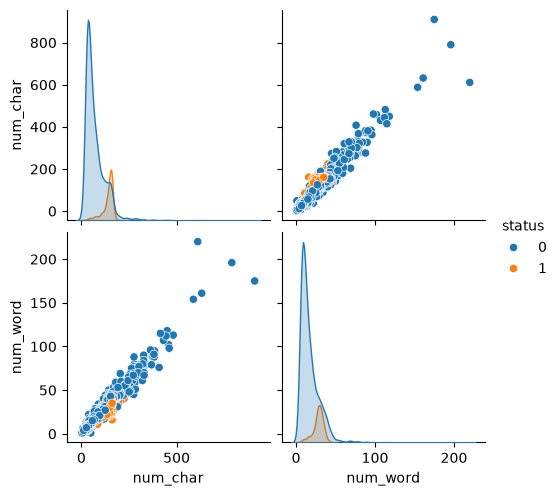

In [ ]:
sns.pairplot(df, hue='status')

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\somee\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [ ]:
ps = PorterStemmer()

In [ ]:
from string import punctuation
from nltk.corpus import stopwords
def convert(text):
    text = text.lower()
    x = nltk.word_tokenize(text)
    
    #keep alpha nuberic characters only
    res = []
    for let in x:
        if let.isalnum():
            res.append(let)
         
    res2 = res[:]
    res.clear()
    for let in res2:
        if let not in punctuation and let not in stopwords.words('english'):
            res.append(let)
    
    
    res2 = res[:]
    res.clear()
    
    for let in res2:
        res.append(ps.stem(let))
    
            
    return " ".join(res)

In [ ]:
convert("Hey someeran !!! how re you... 2bhai let's grab some drink and learn machine learning")

'hey someeran 2bhai let grab drink learn machin learn'

In [ ]:
dt = df[['status', 'num_char', 'num_word']]
dt.corr()


,status,num_char,num_word
status,1.000000,0.384717,0.262912
num_char,0.384717,1.000000,0.965760
num_word,0.262912,0.965760,1.000000


In [ ]:
#df['text'] = df['v2'].apply(convert)